# ResNet50 — Transfer Learning pour la détection d'anomalies

## Objectif
Comparer **ResNet50** (fine-tuné) avec **EfficientNetB0** et l'**Autoencoder** sur le dataset MVTec AD.

## Pipeline
1. ResNet50 pré-entraîné sur ImageNet → fine-tuning
2. Classification binaire : good (0) vs défectueux (1)
3. Grad-CAM pour visualiser les décisions
4. Comparaison avec EfficientNetB0 (AUC ~0.99) et AE (AUC ~0.96)


In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Seeds
np.random.seed(42)
tf.random.set_seed(42)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print(f"✅ TensorFlow {tf.__version__}")
print(f"   GPU : {tf.config.list_physical_devices('GPU')}")

✅ TensorFlow 2.21.0
   GPU : []


In [2]:
# ⚙️ Paramètres
BASE_DIR = "Dataset_128"
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS_HEAD = 20
EPOCHS_FINETUNE = 20

# 15 catégories MVTec AD
CATEGORIES = [
    "bottle", "cable", "capsule", "carpet", "grid",
    "hazelnut", "leather", "metal_nut", "pill", "screw",
    "tile", "toothbrush", "transistor", "wood", "zipper"
]

print(f"📁 Dataset   : {BASE_DIR}/")
print(f"📏 Taille    : {IMG_SIZE}×{IMG_SIZE}")
print(f"🔢 Batch     : {BATCH_SIZE}")
print(f"📂 Catégories: {len(CATEGORIES)}")

📁 Dataset   : Dataset_128/
📏 Taille    : 128×128
🔢 Batch     : 32
📂 Catégories: 15


## 1. Chargement des données

In [3]:
def load_dataset(base_dir, category, img_size=(IMG_SIZE, IMG_SIZE)):
    images, labels = [], []
    train_dir = os.path.join(base_dir, "Train", category, "good")
    for fname in os.listdir(train_dir):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = load_img(os.path.join(train_dir, fname), target_size=img_size, color_mode='rgb')
            images.append(img_to_array(img))
            labels.append(0)
    test_dir = os.path.join(base_dir, "Test", category)
    for defect_type in sorted(os.listdir(test_dir)):
        folder = os.path.join(test_dir, defect_type)
        if not os.path.isdir(folder): continue
        label = 0 if defect_type == "good" else 1
        for fname in os.listdir(folder):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                img = load_img(os.path.join(folder, fname), target_size=img_size, color_mode='rgb')
                images.append(img_to_array(img))
                labels.append(label)
    return np.array(images), np.array(labels)

def build_resnet_model():
    """Construit un modèle ResNet50 + tête de classification."""
    backbone = ResNet50(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling='avg'
    )
    backbone.trainable = False
    
    data_aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),
    ], name="data_augmentation")
    
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_aug(inputs)
    x = tf.keras.applications.resnet.preprocess_input(x)
    x = backbone(x, training=False)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs), backbone

def train_evaluate(category):
    """Entraîne et évalue ResNet50 sur une catégorie."""
    print(f"\n{'='*60}")
    print(f"{'🔍 ResNet50 — ' + category:^60}")
    print(f"{'='*60}")
    t0 = time.time()
    
    X, y = load_dataset(BASE_DIR, category)
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42)
    print(f"   Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]} (good: {(y_test==0).sum()}, def: {(y_test==1).sum()})")
    
    model, backbone = build_resnet_model()
    callbacks = [
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,
                                      monitor='val_auc', mode='max', verbose=0),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-7, verbose=0),
    ]
    
    # Phase 1 : Head (backbone frozen)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS_HEAD,
              validation_data=(X_val, y_val), callbacks=callbacks, verbose=0)
    
    # Phase 2 : Fine-tuning
    backbone.trainable = True
    for layer in backbone.layers[:-30]:
        layer.trainable = False
    
    model.compile(optimizer=keras.optimizers.Adam(1e-5), loss='binary_crossentropy',
                  metrics=['accuracy', keras.metrics.AUC(name='auc')])
    model.fit(X_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS_FINETUNE,
              validation_data=(X_val, y_val), callbacks=callbacks, verbose=0)
    
    y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
    auc = roc_auc_score(y_test, y_prob)
    
    elapsed = time.time() - t0
    
    # Métriques détaillées
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    best_thresh = thresholds[best_idx]
    y_pred = (y_prob >= best_thresh).astype(int)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    print(f"\n📊 AUC={auc:.4f} | ⏱️ {elapsed:.1f}s")
    print(f"🎯 Seuil={best_thresh:.4f} | ✅ Accuracy={accuracy:.4f} | Precision={precision:.4f} | Recall={recall:.4f} | F1={f1:.4f}")
    print(f"   VP={tp} FP={fp} | FN={fn} VN={tn}")
    
    # ROC + Confusion Matrix
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.8))
    ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax1.scatter(fpr[best_idx], tpr[best_idx], color='red', s=60, zorder=5,
                label=f'Seuil = {best_thresh:.4f}')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve — {category}', fontsize=11, fontweight='bold')
    ax1.legend(fontsize=8, loc='lower right')
    ax1.set_xlim(-0.02, 1.02); ax1.set_ylim(-0.02, 1.02)
    
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Good', 'Defect'],
        cmap='Blues', ax=ax2, colorbar=False, values_format='d'
    )
    ax2.set_title(f'Confusion Matrix — {category}', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return {
        "auc": auc, "time": elapsed, "accuracy": accuracy,
        "precision": precision, "recall": recall, "f1": f1,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp, "threshold": best_thresh,
        "y_test": y_test, "y_prob": y_prob
    }

print("✅ Fonctions prêtes")

✅ Fonctions prêtes



                    🔍 ResNet50 — bottle                     
   Train: 341 | Val: 61 | Test: 72 (good: 62, def: 10)

📊 AUC=0.9710 | ⏱️ 136.0s
🎯 Seuil=0.9351 | ✅ Accuracy=0.9444 | Precision=0.7500 | Recall=0.9000 | F1=0.8182
   VP=9 FP=3 | FN=1 VN=59


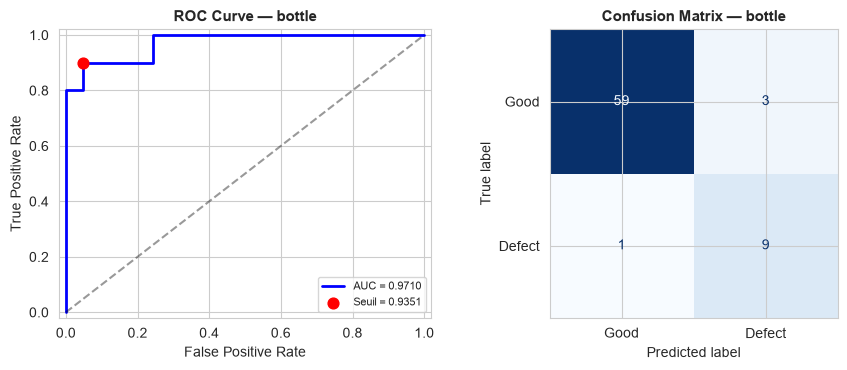


                     🔍 ResNet50 — cable                     
   Train: 390 | Val: 69 | Test: 82 (good: 68, def: 14)

📊 AUC=0.9821 | ⏱️ 162.4s
🎯 Seuil=0.1013 | ✅ Accuracy=0.9024 | Precision=0.6364 | Recall=1.0000 | F1=0.7778
   VP=14 FP=8 | FN=0 VN=60


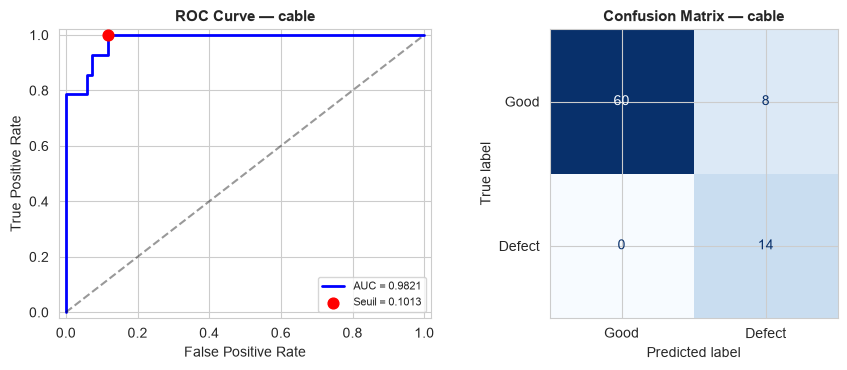


                    🔍 ResNet50 — capsule                    
   Train: 377 | Val: 67 | Test: 79 (good: 63, def: 16)

📊 AUC=0.8046 | ⏱️ 194.8s
🎯 Seuil=0.4486 | ✅ Accuracy=0.6329 | Precision=0.3488 | Recall=0.9375 | F1=0.5085
   VP=15 FP=28 | FN=1 VN=35


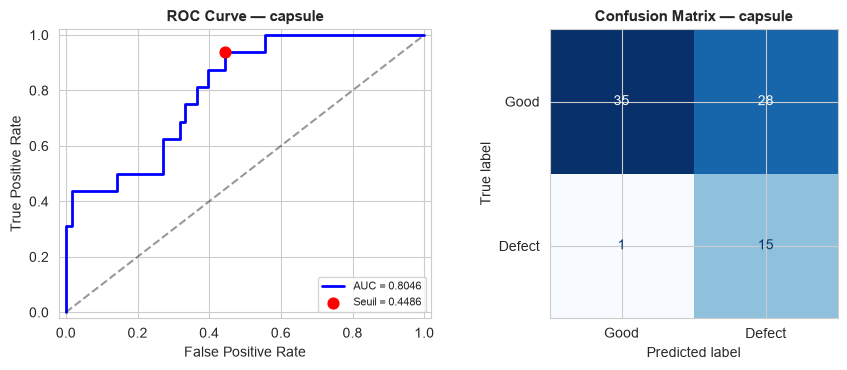


                    🔍 ResNet50 — carpet                     
   Train: 366 | Val: 65 | Test: 77 (good: 64, def: 13)

📊 AUC=0.9399 | ⏱️ 132.5s
🎯 Seuil=0.4032 | ✅ Accuracy=0.9740 | Precision=1.0000 | Recall=0.8462 | F1=0.9167
   VP=11 FP=0 | FN=2 VN=64


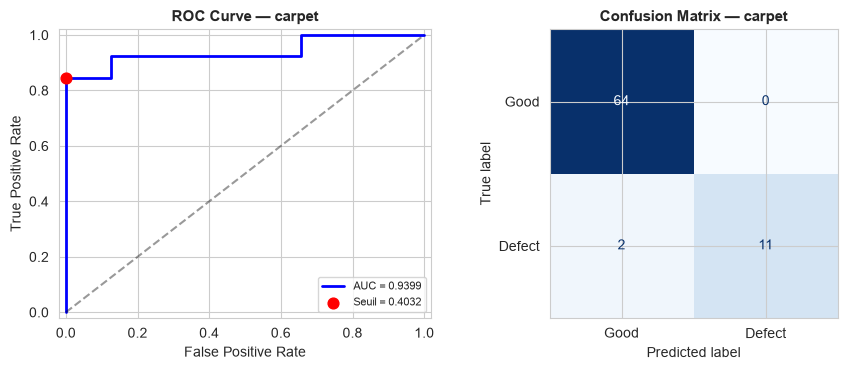


                     🔍 ResNet50 — grid                      
   Train: 338 | Val: 60 | Test: 71 (good: 62, def: 9)

📊 AUC=0.7975 | ⏱️ 124.0s
🎯 Seuil=0.2714 | ✅ Accuracy=0.8169 | Precision=0.3750 | Recall=0.6667 | F1=0.4800
   VP=6 FP=10 | FN=3 VN=52


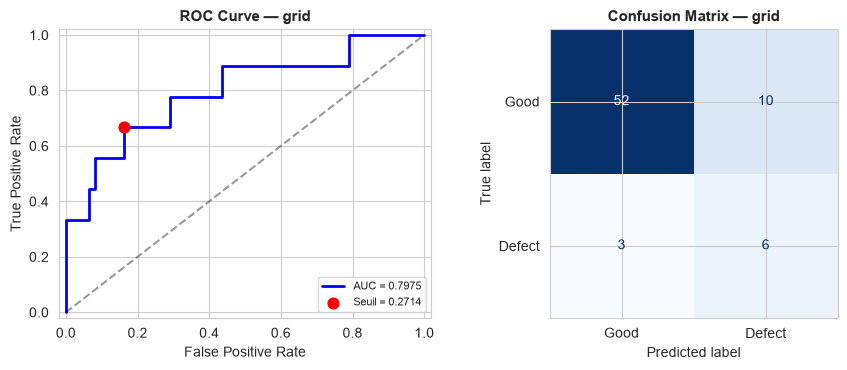


                   🔍 ResNet50 — hazelnut                    
   Train: 361 | Val: 64 | Test: 76 (good: 65, def: 11)

📊 AUC=0.9762 | ⏱️ 90.8s
🎯 Seuil=0.2649 | ✅ Accuracy=0.9605 | Precision=0.7857 | Recall=1.0000 | F1=0.8800
   VP=11 FP=3 | FN=0 VN=62


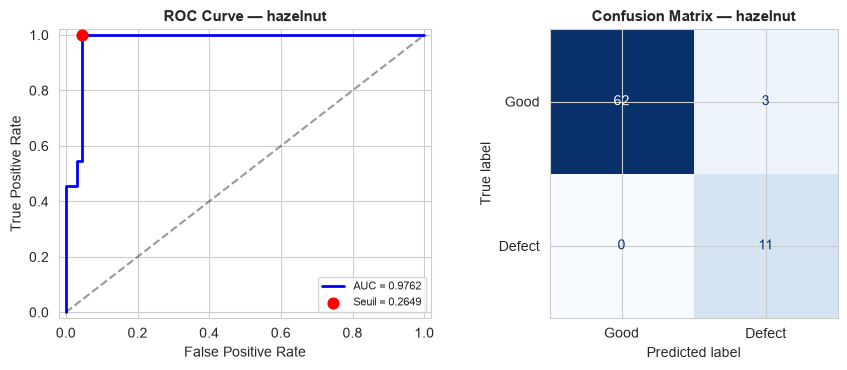


                    🔍 ResNet50 — leather                    
   Train: 371 | Val: 66 | Test: 78 (good: 64, def: 14)

📊 AUC=1.0000 | ⏱️ 90.4s
🎯 Seuil=0.2235 | ✅ Accuracy=1.0000 | Precision=1.0000 | Recall=1.0000 | F1=1.0000
   VP=14 FP=0 | FN=0 VN=64


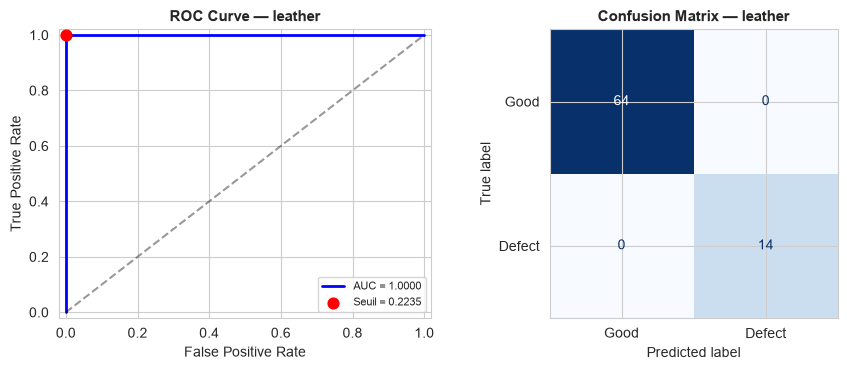


                   🔍 ResNet50 — metal_nut                   
   Train: 365 | Val: 65 | Test: 76 (good: 62, def: 14)

📊 AUC=0.9459 | ⏱️ 151.1s
🎯 Seuil=0.1593 | ✅ Accuracy=0.8816 | Precision=0.6190 | Recall=0.9286 | F1=0.7429
   VP=13 FP=8 | FN=1 VN=54


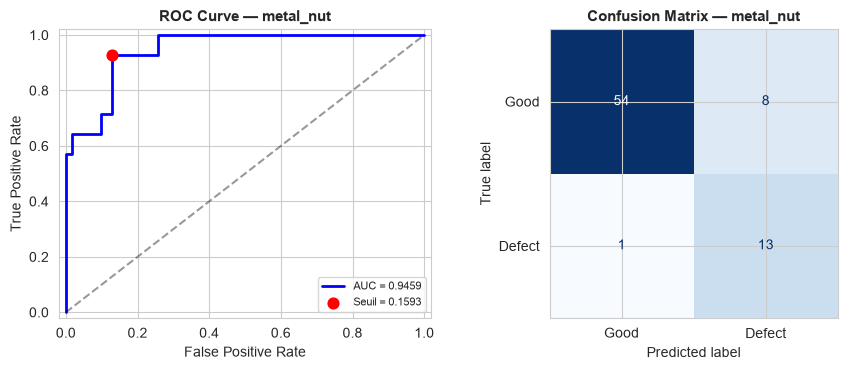


                     🔍 ResNet50 — pill                      
   Train: 402 | Val: 72 | Test: 84 (good: 63, def: 21)

📊 AUC=0.8587 | ⏱️ 146.8s
🎯 Seuil=0.4166 | ✅ Accuracy=0.7857 | Precision=0.5455 | Recall=0.8571 | F1=0.6667
   VP=18 FP=15 | FN=3 VN=48


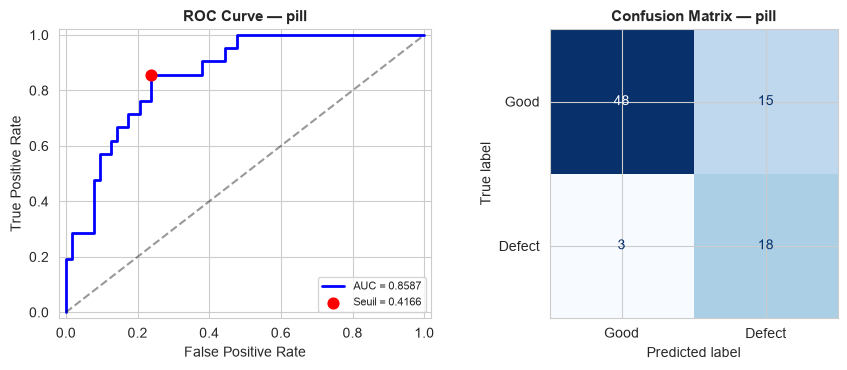


                     🔍 ResNet50 — screw                     
   Train: 397 | Val: 71 | Test: 83 (good: 65, def: 18)

📊 AUC=0.9265 | ⏱️ 73.9s
🎯 Seuil=0.4278 | ✅ Accuracy=0.8193 | Precision=0.5517 | Recall=0.8889 | F1=0.6809
   VP=16 FP=13 | FN=2 VN=52


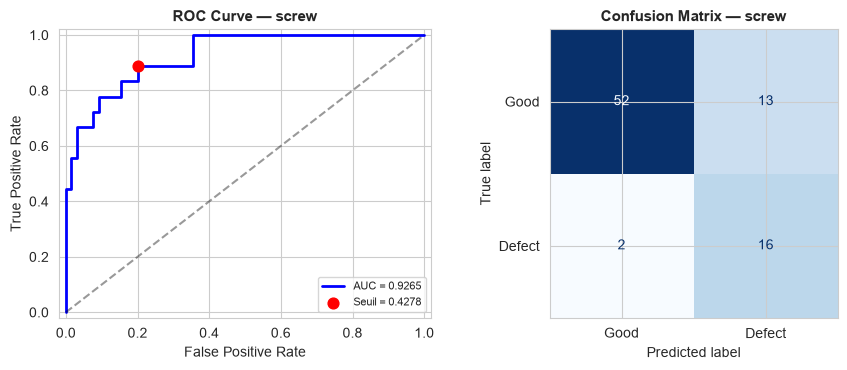


                     🔍 ResNet50 — tile                      
   Train: 366 | Val: 65 | Test: 77 (good: 64, def: 13)

📊 AUC=0.9976 | ⏱️ 53.9s
🎯 Seuil=0.3626 | ✅ Accuracy=0.9740 | Precision=0.8667 | Recall=1.0000 | F1=0.9286
   VP=13 FP=2 | FN=0 VN=62


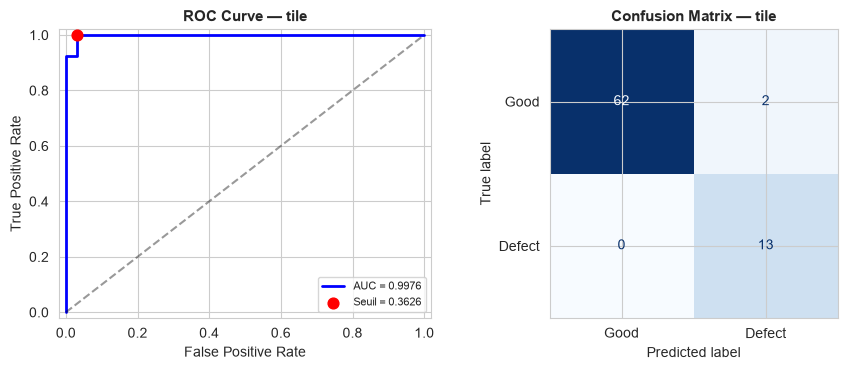


                  🔍 ResNet50 — toothbrush                   
   Train: 312 | Val: 56 | Test: 65 (good: 60, def: 5)

📊 AUC=0.8967 | ⏱️ 54.9s
🎯 Seuil=0.1942 | ✅ Accuracy=0.8615 | Precision=0.3333 | Recall=0.8000 | F1=0.4706
   VP=4 FP=8 | FN=1 VN=52


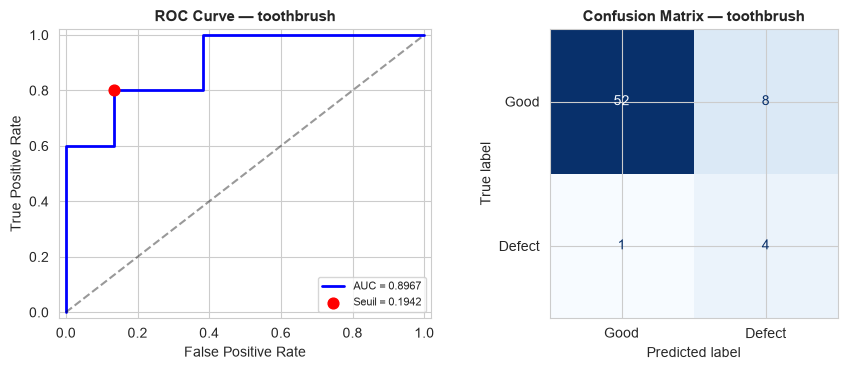


                  🔍 ResNet50 — transistor                   
   Train: 354 | Val: 63 | Test: 74 (good: 68, def: 6)

📊 AUC=0.9681 | ⏱️ 51.5s
🎯 Seuil=0.3795 | ✅ Accuracy=0.9865 | Precision=1.0000 | Recall=0.8333 | F1=0.9091
   VP=5 FP=0 | FN=1 VN=68


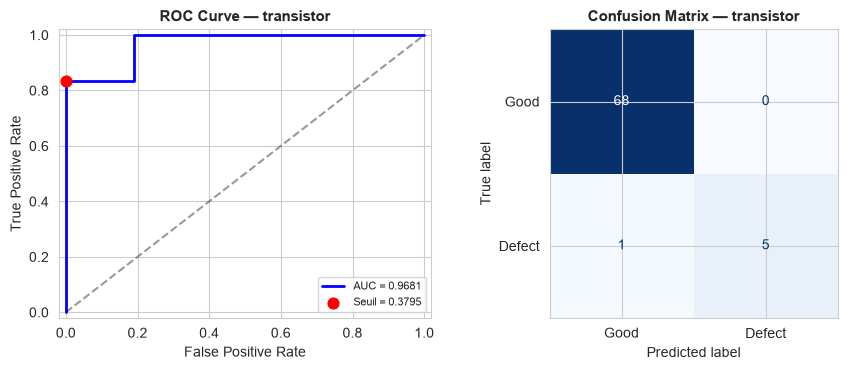


                     🔍 ResNet50 — wood                      
   Train: 339 | Val: 60 | Test: 71 (good: 62, def: 9)

📊 AUC=0.9247 | ⏱️ 66.0s
🎯 Seuil=0.2018 | ✅ Accuracy=0.9577 | Precision=0.8750 | Recall=0.7778 | F1=0.8235
   VP=7 FP=1 | FN=2 VN=61


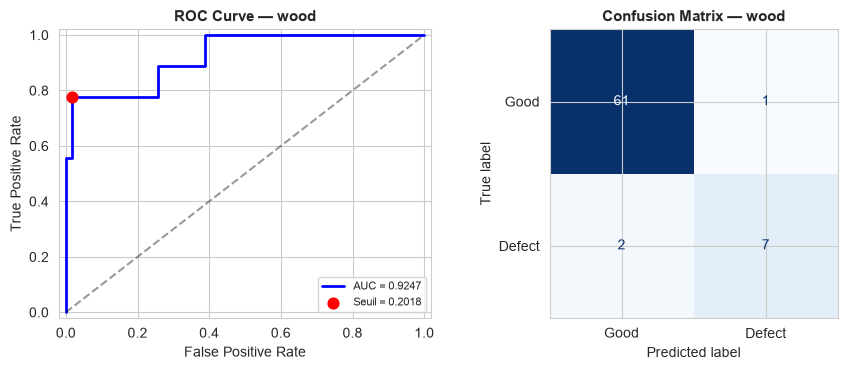


                    🔍 ResNet50 — zipper                     
   Train: 391 | Val: 69 | Test: 82 (good: 64, def: 18)

📊 AUC=0.9635 | ⏱️ 69.2s
🎯 Seuil=0.6585 | ✅ Accuracy=0.9268 | Precision=0.8000 | Recall=0.8889 | F1=0.8421
   VP=16 FP=4 | FN=2 VN=60


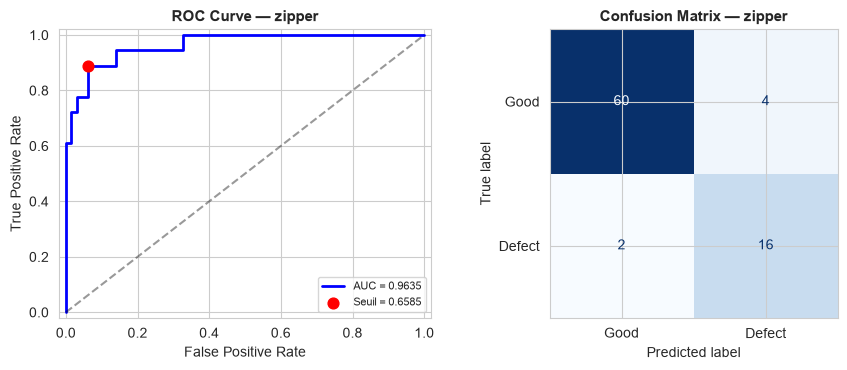



                 📊 BENCHMARK ResNet50 — 15 catégories                 
Catégorie            AUC    Temps
-------------------------------
bottle            0.9710   136.0s
cable             0.9821   162.4s
capsule           0.8046   194.8s
carpet            0.9399   132.5s
grid              0.7975   124.0s
hazelnut          0.9762    90.8s
leather           1.0000    90.4s
metal_nut         0.9459   151.1s
pill              0.8587   146.8s
screw             0.9265    73.9s
tile              0.9976    53.9s
toothbrush        0.8967    54.9s
transistor        0.9681    51.5s
wood              0.9247    66.0s
zipper            0.9635    69.2s
-------------------------------
MOYENNE           0.9302
TOTAL                     1599.4s


In [4]:
# ---- Boucle sur toutes les catégories ----
results = {}
all_preds = {}
t_start = time.time()

for category in CATEGORIES:
    info = train_evaluate(category)
    results[category] = {k: info[k] for k in ["auc", "time", "accuracy", "precision", "recall", "f1", "tn", "fp", "fn", "tp", "threshold"]}
    all_preds[category] = {"y_test": info["y_test"], "y_prob": info["y_prob"]}

# ---- Résumé final ----
total_time = time.time() - t_start
print(f"\n\n{'='*70}")
print(f"{'📊 BENCHMARK ResNet50 — 15 catégories':^70}")
print(f"{'='*70}")
print(f"{'Catégorie':<15} {'AUC':>8} {'Temps':>8}")
print(f"{'-'*31}")
for cat in CATEGORIES:
    r = results[cat]
    print(f"{cat:<15} {r['auc']:>8.4f} {r['time']:>7.1f}s")
print(f"{'-'*31}")
mean_auc = np.mean([r['auc'] for r in results.values()])
print(f"{'MOYENNE':<15} {mean_auc:>8.4f}")
print(f"{'TOTAL':<15} {'':>8} {total_time:>7.1f}s")
print(f"{'='*70}")

## 2. Synthèse visuelle — Toutes les catégories


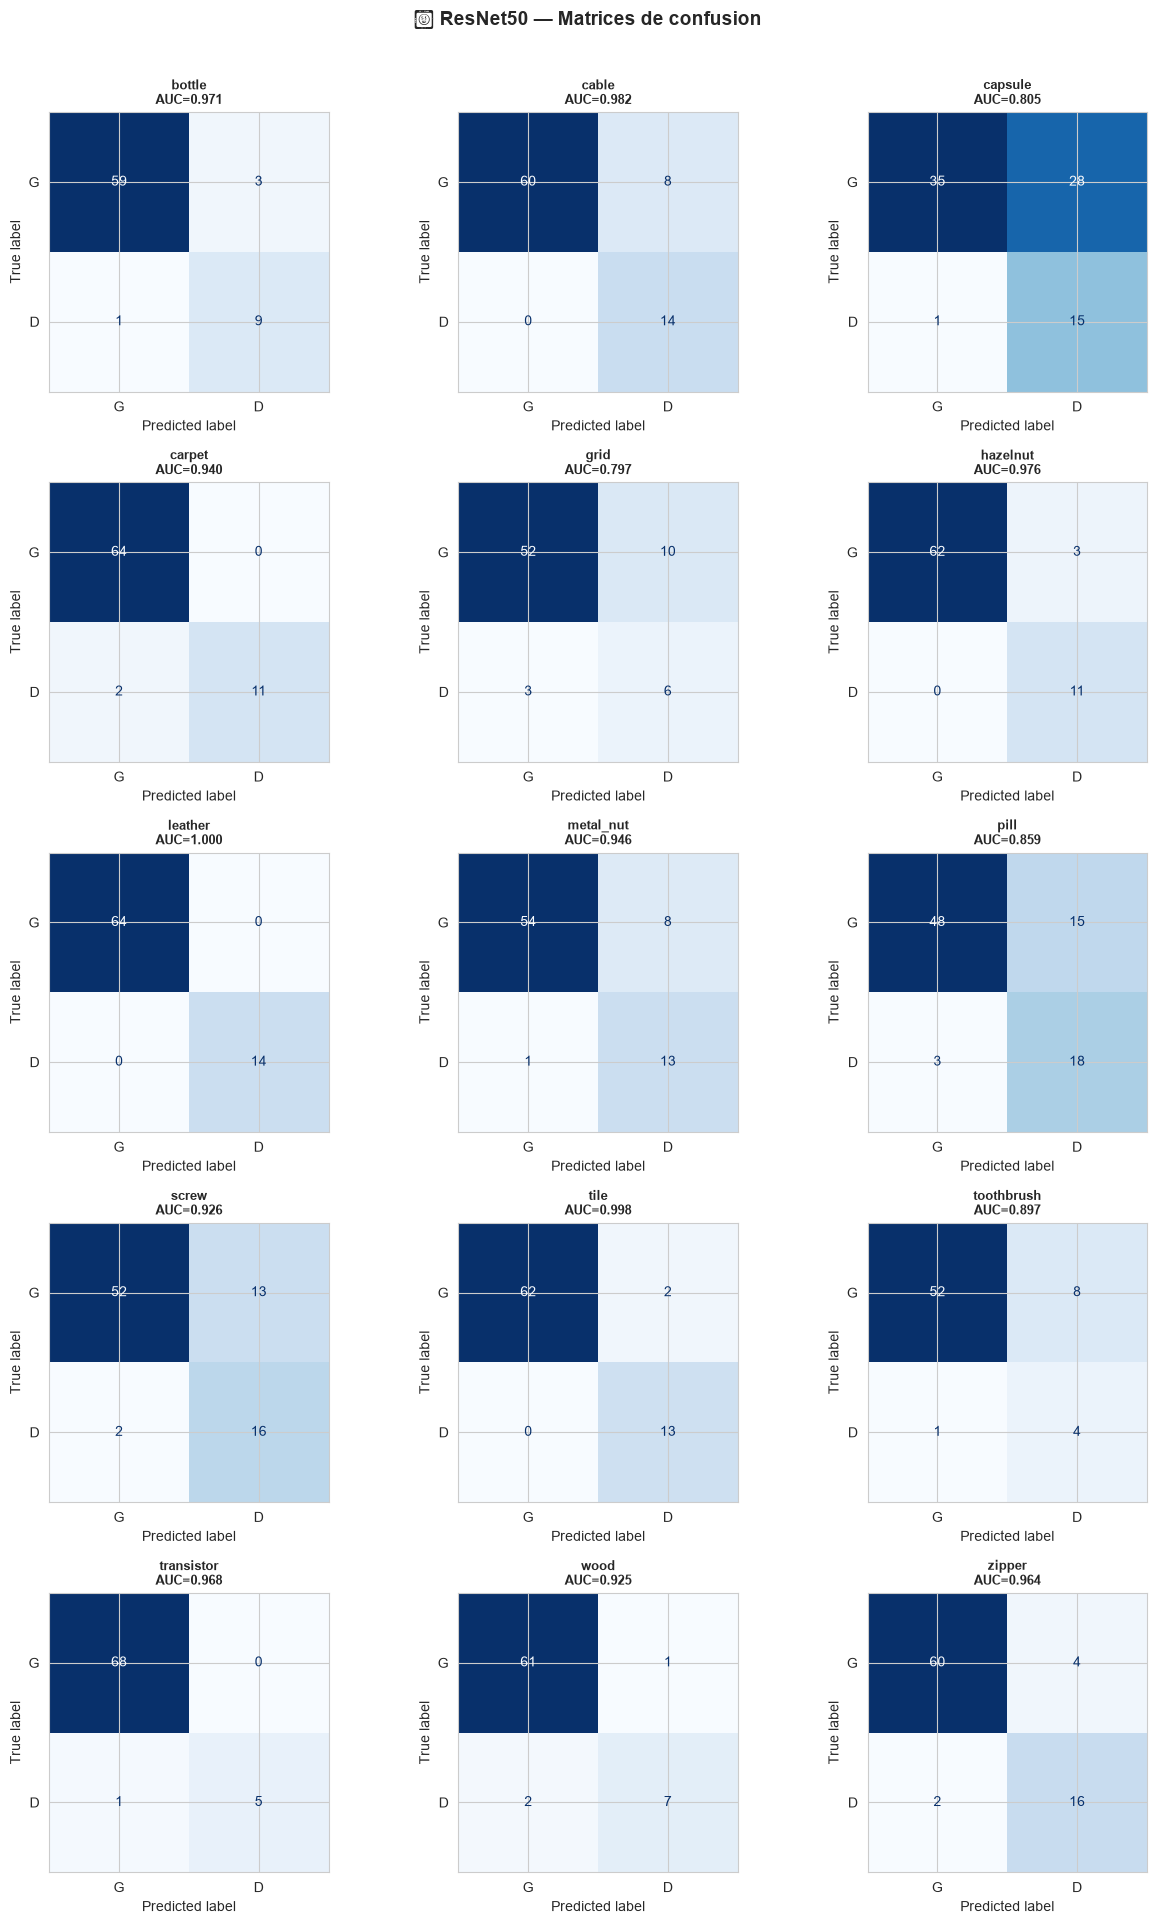


                                   📊 SYNTHÈSE COMPLÈTE — ResNet50                                   
Catégorie          AUC     Seuil  Accuracy  Precision   Recall      F1   VP   FP   FN   VN
----------------------------------------------------------------------------------------------------
bottle           0.971    0.9351     0.944      0.750    0.900   0.818    9    3    1   59
cable            0.982    0.1013     0.902      0.636    1.000   0.778   14    8    0   60
capsule          0.805    0.4486     0.633      0.349    0.938   0.508   15   28    1   35
carpet           0.940    0.4032     0.974      1.000    0.846   0.917   11    0    2   64
grid             0.797    0.2714     0.817      0.375    0.667   0.480    6   10    3   52
hazelnut         0.976    0.2649     0.961      0.786    1.000   0.880   11    3    0   62
leather          1.000    0.2235     1.000      1.000    1.000   1.000   14    0    0   64
metal_nut        0.946    0.1593     0.882      0.619    0.929   0.74

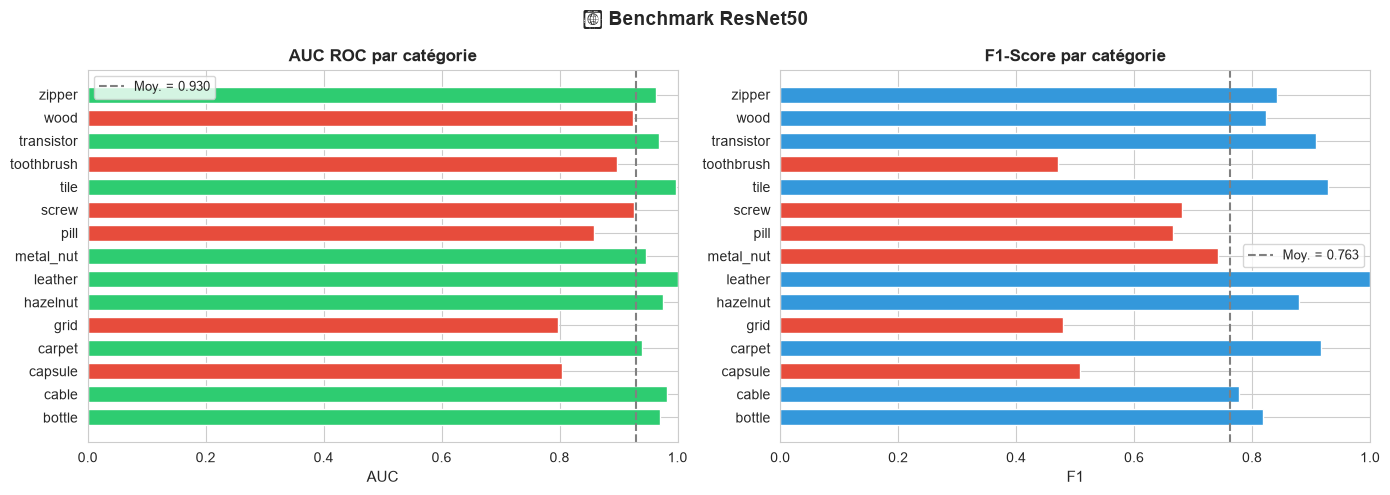

In [5]:
# ─── Synthèse : grille des matrices + histogrammes ───

if 'all_preds' not in dir() or len(all_preds) == 0:
    print("⚠️  `all_preds` est vide. Exécute d'abord la cellule d'entraînement.")
else:
    # ── 1. Grille des matrices de confusion ──
    n_cats = len(CATEGORIES)
    n_cols = 3
    n_rows = int(np.ceil(n_cats / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.2, n_rows * 3.8))
    axes = axes.flatten()
    
    for idx, cat in enumerate(CATEGORIES):
        ax = axes[idx]
        y_true = all_preds[cat]["y_test"]
        y_prob = all_preds[cat]["y_prob"]
        
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        best_t = thresholds[np.argmax(tpr - fpr)]
        y_pred = (y_prob >= best_t).astype(int)
        
        ConfusionMatrixDisplay.from_predictions(
            y_true, y_pred, display_labels=['G', 'D'],
            cmap='Blues', ax=ax, colorbar=False, values_format='d'
        )
        ax.set_title(f'{cat}\nAUC={roc_auc_score(y_true, y_prob):.3f}',
                     fontsize=9, fontweight='bold')
    
    for idx in range(n_cats, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('🧩 ResNet50 — Matrices de confusion',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    
    # ── 2. Tableau récapitulatif ──
    metrics_list = ['auc', 'accuracy', 'precision', 'recall', 'f1']
    print(f"\n{'='*100}")
    print(f"{'📊 SYNTHÈSE COMPLÈTE — ResNet50':^100}")
    print(f"{'='*100}")
    print(f"{'Catégorie':<14} {'AUC':>7} {'Seuil':>9} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>7} {'VP':>4} {'FP':>4} {'FN':>4} {'VN':>4}")
    print(f"{'-'*100}")
    
    all_vals = {k: [] for k in metrics_list}
    for cat in CATEGORIES:
        r = results[cat]
        print(f"{cat:<14} {r['auc']:>7.3f} {r['threshold']:>9.4f} {r['accuracy']:>9.3f} {r['precision']:>10.3f} {r['recall']:>8.3f} {r['f1']:>7.3f} {r['tp']:>4} {r['fp']:>4} {r['fn']:>4} {r['tn']:>4}")
        for k in metrics_list:
            all_vals[k].append(r[k])
    
    print(f"{'-'*100}")
    print(f"{'MOYENNE':<14}", end='')
    for k in metrics_list:
        print(f" {np.mean(all_vals[k]):>7.3f}", end=' ' if k != 'f1' else '')
    print(f"{'':->28}")
    print(f"{'ÉCART-TYPE':<14}", end='')
    for k in metrics_list:
        print(f" {np.std(all_vals[k]):>7.3f}", end=' ' if k != 'f1' else '')
    print(f"\n{'='*100}")
    
    # ── 3. Barres horizontales ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, title, color in [
        (axes[0], 'auc', 'AUC ROC', '#2ecc71'),
        (axes[1], 'f1', 'F1-Score', '#3498db')
    ]:
        vals = [results[cat][metric] for cat in CATEGORIES]
        colors = [color if v >= np.mean(vals) else '#e74c3c' for v in vals]
        ax.barh(CATEGORIES, vals, color=colors, edgecolor='white', height=0.7)
        ax.axvline(np.mean(vals), color='gray', linestyle='--',
                    label=f'Moy. = {np.mean(vals):.3f}')
        ax.set_xlabel(metric.upper(), fontsize=11)
        ax.set_title(f'{title} par catégorie', fontsize=12, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.legend(fontsize=9)
    
    plt.suptitle('📊 Benchmark ResNet50', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()